# Лабораторная работа №1
  
## Тема: Предобработка данных
  
## Цель работы: Ознакомиться с методами предобработки данных из библиотеки Scikit Learn.

**Студент:** Магомедов Имран Борисович  
**Группа:** ПИЖ-Б-О-22-1  
**Курс/Семестр:** 4/8  

## Методика и порядок выполнения работы

### Загрузка данных

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1. Загрузка датасета

In [56]:
df = pd.read_csv('/content/drive/MyDrive/NCFU/ОиАБД/Отчеты/Лабораторная работа №1/heart_failure_clinical_records_dataset.csv')

2. Исключение бинарных признаков и признака времени

In [57]:
df = df.drop(columns = ['anaemia','diabetes','high_blood_pressure','sex','smoking','time','DEATH_EVENT'])
print(df) # Вывод датафрейма с данными для лаб. работы. Должно быть 299 наблюдений и 6 признаков
print(f"\nРазмер датафрейма: {df.shape}")

      age  creatinine_phosphokinase  ejection_fraction  platelets  \
0    75.0                       582                 20  265000.00   
1    55.0                      7861                 38  263358.03   
2    65.0                       146                 20  162000.00   
3    50.0                       111                 20  210000.00   
4    65.0                       160                 20  327000.00   
..    ...                       ...                ...        ...   
294  62.0                        61                 38  155000.00   
295  55.0                      1820                 38  270000.00   
296  45.0                      2060                 60  742000.00   
297  45.0                      2413                 38  140000.00   
298  50.0                       196                 45  395000.00   

     serum_creatinine  serum_sodium  
0                 1.9           130  
1                 1.1           136  
2                 1.3           129  
3                 1

3. Построение гистограмм признаков

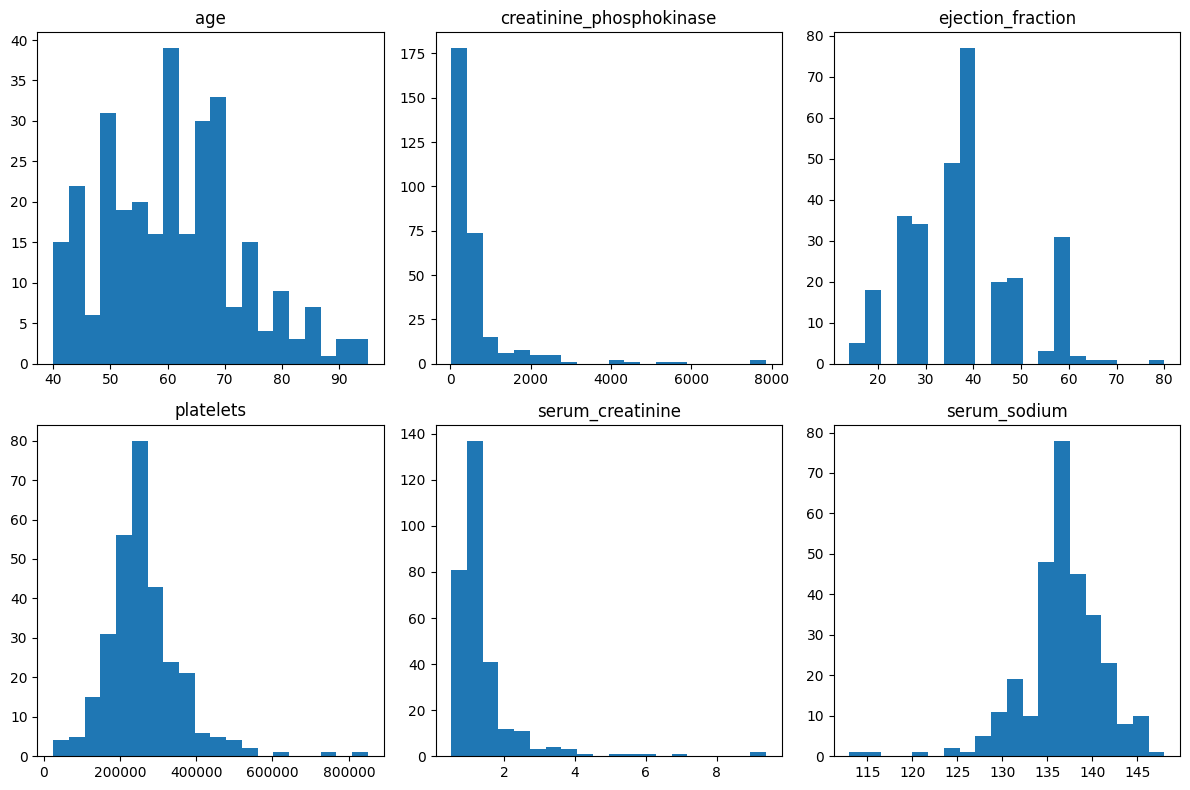

In [58]:
n_bins = 20
fig, axs = plt.subplots(2, 3)
fig.set_size_inches(12, 8)

axs[0, 0].hist(df['age'].values, bins = n_bins)
axs[0, 0].set_title('age')
axs[0, 1].hist(df['creatinine_phosphokinase'].values, bins = n_bins)
axs[0, 1].set_title('creatinine_phosphokinase')
axs[0, 2].hist(df['ejection_fraction'].values, bins = n_bins)
axs[0, 2].set_title('ejection_fraction')
axs[1, 0].hist(df['platelets'].values, bins = n_bins)
axs[1, 0].set_title('platelets')
axs[1, 1].hist(df['serum_creatinine'].values, bins = n_bins)
axs[1, 1].set_title('serum_creatinine')
axs[1, 2].hist(df['serum_sodium'].values, bins = n_bins)
axs[1, 2].set_title('serum_sodium')

plt.tight_layout()
plt.show()

4. Анализ гистограмм (вывод в консоль)

Анализ гистограмм:

- age: диапазон ~40-95 лет, наибольшее количество наблюдений ~60-65 лет

- creatinine_phosphokinase: диапазон ~20-8000, наибольшее количество наблюдений ~0-200

- ejection_fraction: диапазон ~15-80%, наибольшее количество наблюдений ~35-40%

- platelets: диапазон ~25000-850000, наибольшее количество наблюдений ~200000-300000

- serum_creatinine: диапазон ~0.5-9.5, наибольшее количество наблюдений ~1.0-1.5

- serum_sodium: диапазон ~110-150, наибольшее количество наблюдений ~135-140

5. Преобразование датафрейма к двумерному массиву NumPy

In [59]:
data = df.to_numpy(dtype='float')
print(f"\nРазмер массива data: {data.shape}")


Размер массива data: (299, 6)


## Стандартизация данных

1. Настройка стандартизации на основе первых 150 наблюдений

In [60]:
from sklearn import preprocessing
scaler = preprocessing.StandardScaler().fit(data[:150,:])

2. Стандартизация всех данных

In [61]:
data_scaled = scaler.transform(data)

3. Построение гистограмм стандартизированных данных

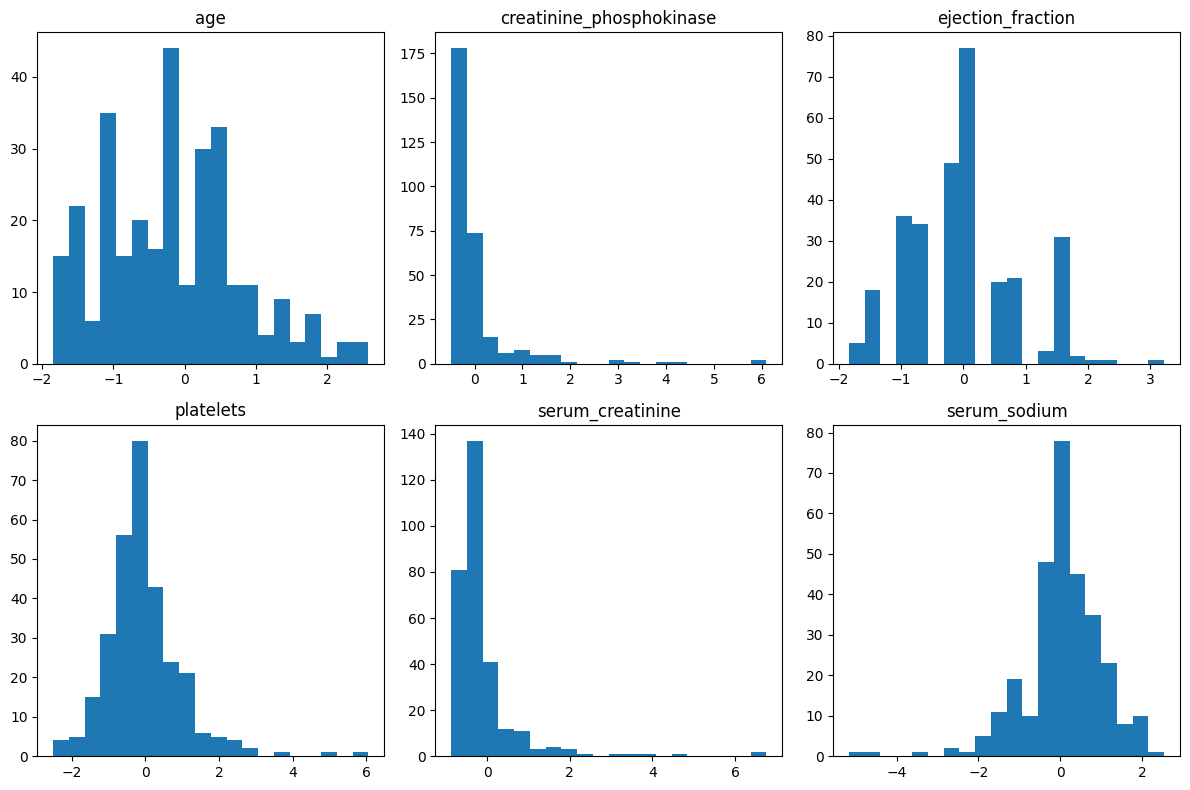

In [62]:
fig, axs = plt.subplots(2, 3)
fig.set_size_inches(12, 8)
axs[0, 0].hist(data_scaled[:,0], bins = n_bins)
axs[0, 0].set_title('age')
axs[0, 1].hist(data_scaled[:,1], bins = n_bins)
axs[0, 1].set_title('creatinine_phosphokinase')
axs[0, 2].hist(data_scaled[:,2], bins = n_bins)
axs[0, 2].set_title('ejection_fraction')
axs[1, 0].hist(data_scaled[:,3], bins = n_bins)
axs[1, 0].set_title('platelets')
axs[1, 1].hist(data_scaled[:,4], bins = n_bins)
axs[1, 1].set_title('serum_creatinine')
axs[1, 2].hist(data_scaled[:,5], bins = n_bins)
axs[1, 2].set_title('serum_sodium')
plt.tight_layout()
plt.show()

4. Сравнение данных до и после стандартизации

Сравнение данных до и после стандартизации:
- До стандартизации: данные имеют разные масштабы и единицы измерения
- После стандартизации: все признаки имеют среднее значение 0 и стандартное отклонение 1
- Форма распределения не изменилась, изменился масштаб осей

5. Расчет мат. ожидания и СКО до и после стандартизации

In [63]:
print("\nДо стандартизации:")
for i, col in enumerate(df.columns):
    print(f"{col}: mean = {data[:,i].mean():.4f}, std = {data[:,i].std():.4f}")

print("\nПосле стандартизации (используя scaler, обученный на первых 150 наблюдениях):")
for i, col in enumerate(df.columns):
    print(f"{col}: mean = {data_scaled[:,i].mean():.4f}, std = {data_scaled[:,i].std():.4f}")

# Формулы стандартизации
print("\n=== Формулы стандартизации ===")
for i, col in enumerate(df.columns):
    mean = scaler.mean_[i]
    scale = scaler.scale_[i]
    print(f"{col}: z = (x - {mean:.4f}) / {scale:.4f}")


До стандартизации:
age: mean = 60.8339, std = 11.8749
creatinine_phosphokinase: mean = 581.8395, std = 968.6640
ejection_fraction: mean = 38.0836, std = 11.8150
platelets: mean = 263358.0293, std = 97640.5477
serum_creatinine: mean = 1.3939, std = 1.0328
serum_sodium: mean = 136.6254, std = 4.4051

После стандартизации (используя scaler, обученный на первых 150 наблюдениях):
age: mean = -0.1697, std = 0.9538
creatinine_phosphokinase: mean = -0.0213, std = 0.8142
ejection_fraction: mean = 0.0105, std = 0.9061
platelets: mean = -0.0352, std = 1.0151
serum_creatinine: mean = -0.1086, std = 0.8854
serum_sodium: mean = 0.0379, std = 0.9704

=== Формулы стандартизации ===
age: z = (x - 62.9467) / 12.4498
creatinine_phosphokinase: z = (x - 607.1533) / 1189.7432
ejection_fraction: z = (x - 37.9467) / 13.0393
platelets: z = (x - 266746.7495) / 96191.7902
serum_creatinine: z = (x - 1.5206) / 1.1664
serum_sodium: z = (x - 136.4533) / 4.5396


6. Сравнение с полями scaler

In [64]:
print("\n=== Значения из полей scaler ===")
print(f"mean_: {scaler.mean_}")
print(f"scale_: {scaler.scale_}")
print("Значения соответствуют рассчитанным формулам")


=== Значения из полей scaler ===
mean_: [6.29466667e+01 6.07153333e+02 3.79466667e+01 2.66746749e+05
 1.52060000e+00 1.36453333e+02]
scale_: [1.24497854e+01 1.18974318e+03 1.30393183e+01 9.61917902e+04
 1.16641630e+00 4.53958393e+00]
Значения соответствуют рассчитанным формулам


7. Настройка стандартизации на всех данных

In [65]:
scaler_all = preprocessing.StandardScaler().fit(data)
data_scaled_all = scaler_all.transform(data)

print("\n=== Сравнение параметров стандартизации ===")
print("Настройка на 150 наблюдений:")
for i, col in enumerate(df.columns):
    print(f"{col}: mean = {scaler.mean_[i]:.4f}, scale = {scaler.scale_[i]:.4f}")

print("\nНастройка на всех данных:")
for i, col in enumerate(df.columns):
    print(f"{col}: mean = {scaler_all.mean_[i]:.4f}, scale = {scaler_all.scale_[i]:.4f}")


=== Сравнение параметров стандартизации ===
Настройка на 150 наблюдений:
age: mean = 62.9467, scale = 12.4498
creatinine_phosphokinase: mean = 607.1533, scale = 1189.7432
ejection_fraction: mean = 37.9467, scale = 13.0393
platelets: mean = 266746.7495, scale = 96191.7902
serum_creatinine: mean = 1.5206, scale = 1.1664
serum_sodium: mean = 136.4533, scale = 4.5396

Настройка на всех данных:
age: mean = 60.8339, scale = 11.8749
creatinine_phosphokinase: mean = 581.8395, scale = 968.6640
ejection_fraction: mean = 38.0836, scale = 11.8150
platelets: mean = 263358.0293, scale = 97640.5477
serum_creatinine: mean = 1.3939, scale = 1.0328
serum_sodium: mean = 136.6254, scale = 4.4051


## Приведение к диапазону

1. MinMaxScaler

In [66]:
min_max_scaler = preprocessing.MinMaxScaler().fit(data)
data_min_max_scaled = min_max_scaler.transform(data)

2. Гистограммы после MinMaxScaler

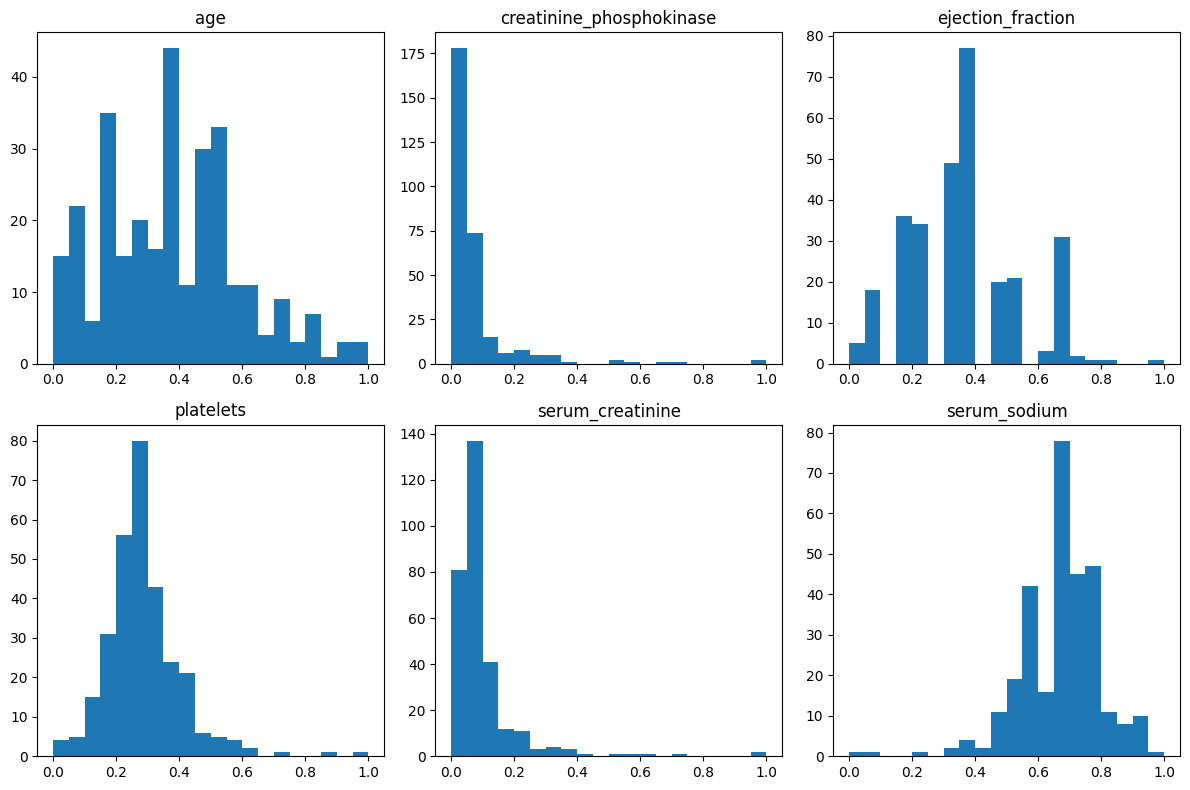

In [67]:
fig, axs = plt.subplots(2, 3)
fig.set_size_inches(12, 8)
axs[0, 0].hist(data_min_max_scaled[:,0], bins = n_bins)
axs[0, 0].set_title('age')
axs[0, 1].hist(data_min_max_scaled[:,1], bins = n_bins)
axs[0, 1].set_title('creatinine_phosphokinase')
axs[0, 2].hist(data_min_max_scaled[:,2], bins = n_bins)
axs[0, 2].set_title('ejection_fraction')
axs[1, 0].hist(data_min_max_scaled[:,3], bins = n_bins)
axs[1, 0].set_title('platelets')
axs[1, 1].hist(data_min_max_scaled[:,4], bins = n_bins)
axs[1, 1].set_title('serum_creatinine')
axs[1, 2].hist(data_min_max_scaled[:,5], bins = n_bins)
axs[1, 2].set_title('serum_sodium')
plt.tight_layout()
plt.show()

3. Минимальные и максимальные значения

In [68]:
print("\n=== MinMaxScaler параметры ===")
print("Минимальные значения (data_min_):", min_max_scaler.data_min_)
print("Максимальные значения (data_max_):", min_max_scaler.data_max_)


=== MinMaxScaler параметры ===
Минимальные значения (data_min_): [4.00e+01 2.30e+01 1.40e+01 2.51e+04 5.00e-01 1.13e+02]
Максимальные значения (data_max_): [9.500e+01 7.861e+03 8.000e+01 8.500e+05 9.400e+00 1.480e+02]


4. MaxAbsScaler и RobustScaler

In [69]:
print("\n=== MaxAbsScaler ===")
max_abs_scaler = preprocessing.MaxAbsScaler().fit(data)
data_max_abs_scaled = max_abs_scaler.transform(data)
print("Диапазон данных: [-1, 1]")

print("\n=== RobustScaler ===")
robust_scaler = preprocessing.RobustScaler().fit(data)
data_robust_scaled = robust_scaler.transform(data)
print("Диапазон данных: основан на медиане и межквартильном размахе")


=== MaxAbsScaler ===
Диапазон данных: [-1, 1]

=== RobustScaler ===
Диапазон данных: основан на медиане и межквартильном размахе


Гистограммы MaxAbsScaler

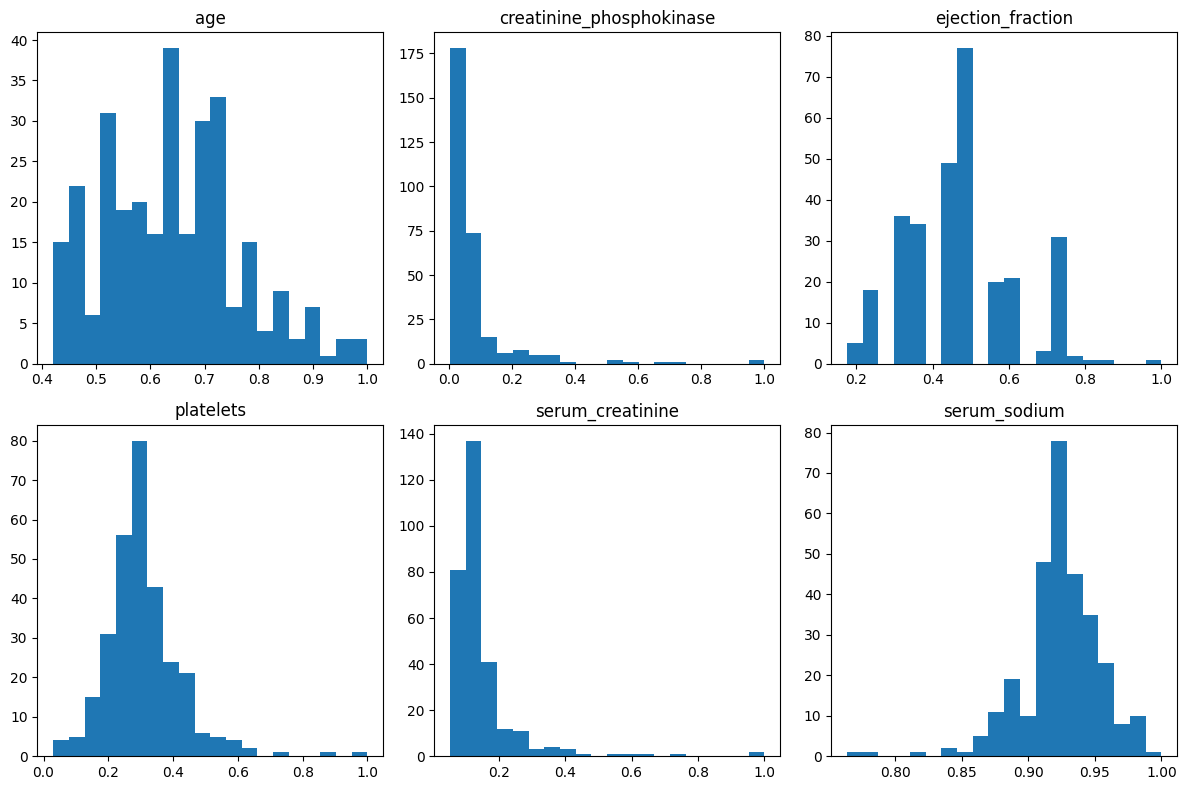

In [70]:
fig, axs = plt.subplots(2, 3)
fig.set_size_inches(12, 8)
axs[0, 0].hist(data_max_abs_scaled[:,0], bins = n_bins)
axs[0, 0].set_title('age')
axs[0, 1].hist(data_max_abs_scaled[:,1], bins = n_bins)
axs[0, 1].set_title('creatinine_phosphokinase')
axs[0, 2].hist(data_max_abs_scaled[:,2], bins = n_bins)
axs[0, 2].set_title('ejection_fraction')
axs[1, 0].hist(data_max_abs_scaled[:,3], bins = n_bins)
axs[1, 0].set_title('platelets')
axs[1, 1].hist(data_max_abs_scaled[:,4], bins = n_bins)
axs[1, 1].set_title('serum_creatinine')
axs[1, 2].hist(data_max_abs_scaled[:,5], bins = n_bins)
axs[1, 2].set_title('serum_sodium')
plt.tight_layout()
plt.show()

Гистограммы RobustScaler

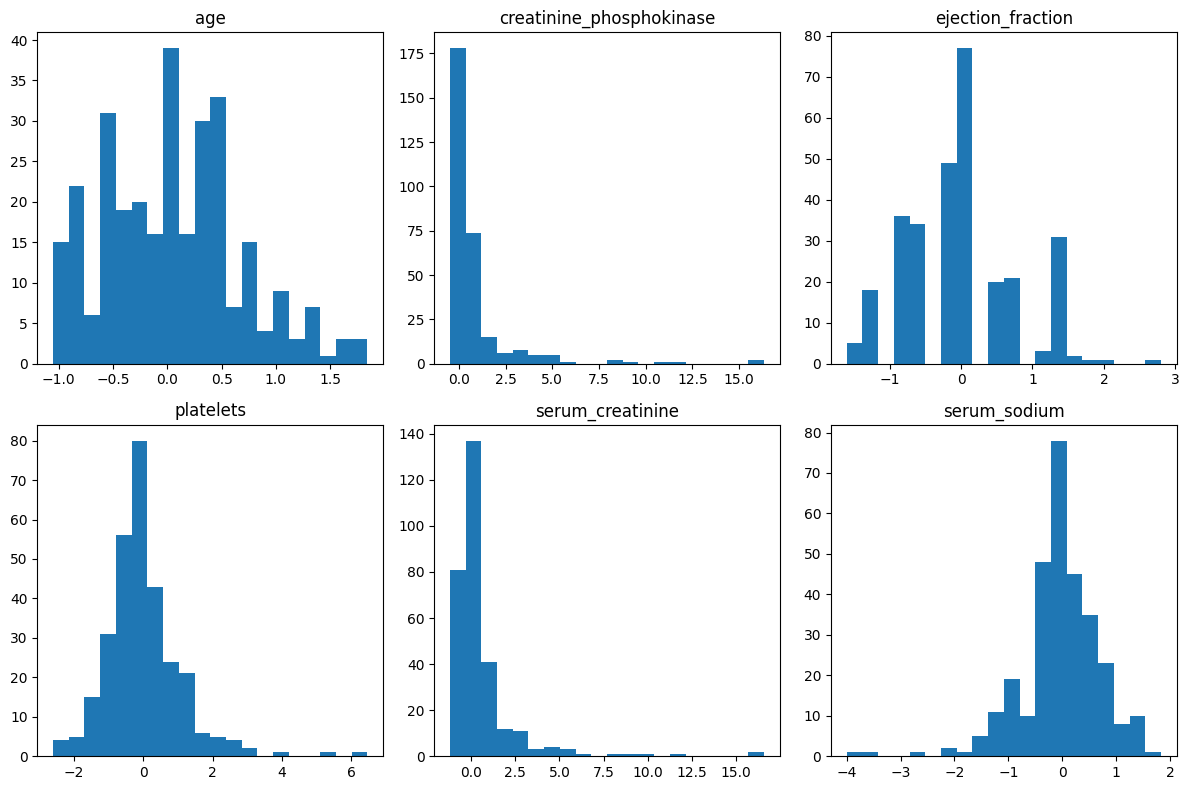

In [71]:
fig, axs = plt.subplots(2, 3)
fig.set_size_inches(12, 8)
axs[0, 0].hist(data_robust_scaled[:,0], bins = n_bins)
axs[0, 0].set_title('age')
axs[0, 1].hist(data_robust_scaled[:,1], bins = n_bins)
axs[0, 1].set_title('creatinine_phosphokinase')
axs[0, 2].hist(data_robust_scaled[:,2], bins = n_bins)
axs[0, 2].set_title('ejection_fraction')
axs[1, 0].hist(data_robust_scaled[:,3], bins = n_bins)
axs[1, 0].set_title('platelets')
axs[1, 1].hist(data_robust_scaled[:,4], bins = n_bins)
axs[1, 1].set_title('serum_creatinine')
axs[1, 2].hist(data_robust_scaled[:,5], bins = n_bins)
axs[1, 2].set_title('serum_sodium')
plt.tight_layout()
plt.show()

5. Функция приведения к диапазону [-5, 10]

In [72]:
def scale_to_range(data, new_min=-5, new_max=10):
    """Приводит данные к заданному диапазону"""
    data_min = data.min(axis=0)
    data_max = data.max(axis=0)
    data_scaled = (data - data_min) / (data_max - data_min)
    data_scaled = data_scaled * (new_max - new_min) + new_min
    return data_scaled

data_custom_scaled = scale_to_range(data)
print("\n=== Пользовательская функция масштабирования ===")
print(f"Диапазон после масштабирования: от {data_custom_scaled.min():.2f} до {data_custom_scaled.max():.2f}")


=== Пользовательская функция масштабирования ===
Диапазон после масштабирования: от -5.00 до 10.00


## Нелинейные преобразования

1. QuantileTransformer к равномерному распределению

In [73]:
quantile_transformer = preprocessing.QuantileTransformer(n_quantiles=100, random_state=0).fit(data)
data_quantile_scaled = quantile_transformer.transform(data)

2. Гистограммы после QuantileTransformer

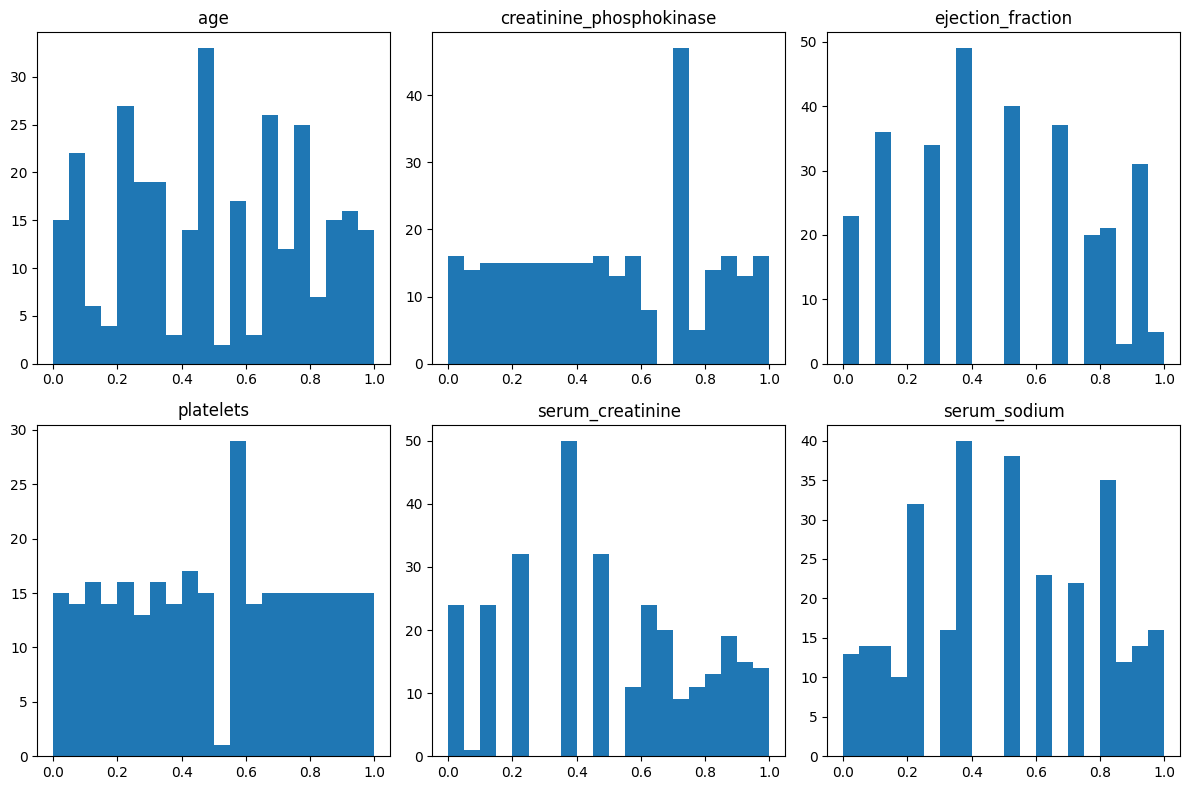

In [74]:
fig, axs = plt.subplots(2, 3)
fig.set_size_inches(12, 8)
axs[0, 0].hist(data_quantile_scaled[:,0], bins = n_bins)
axs[0, 0].set_title('age')
axs[0, 1].hist(data_quantile_scaled[:,1], bins = n_bins)
axs[0, 1].set_title('creatinine_phosphokinase')
axs[0, 2].hist(data_quantile_scaled[:,2], bins = n_bins)
axs[0, 2].set_title('ejection_fraction')
axs[1, 0].hist(data_quantile_scaled[:,3], bins = n_bins)
axs[1, 0].set_title('platelets')
axs[1, 1].hist(data_quantile_scaled[:,4], bins = n_bins)
axs[1, 1].set_title('serum_creatinine')
axs[1, 2].hist(data_quantile_scaled[:,5], bins = n_bins)
axs[1, 2].set_title('serum_sodium')
plt.tight_layout()
plt.show()

# 3. Влияние параметра n_quantiles

QuantileTransformer:
- n_quantiles: количество квантилей, используемых для преобразования
- Влияние: чем больше n_quantiles, тем точнее аппроксимация распределения
- Меньшее значение дает более гладкое преобразование

4. QuantileTransformer к нормальному распределению

In [75]:
quantile_normal = preprocessing.QuantileTransformer(n_quantiles=100, random_state=0, output_distribution='normal').fit(data)
data_quantile_normal = quantile_normal.transform(data)

5. Гистограммы после QuantileTransformer (нормальное)

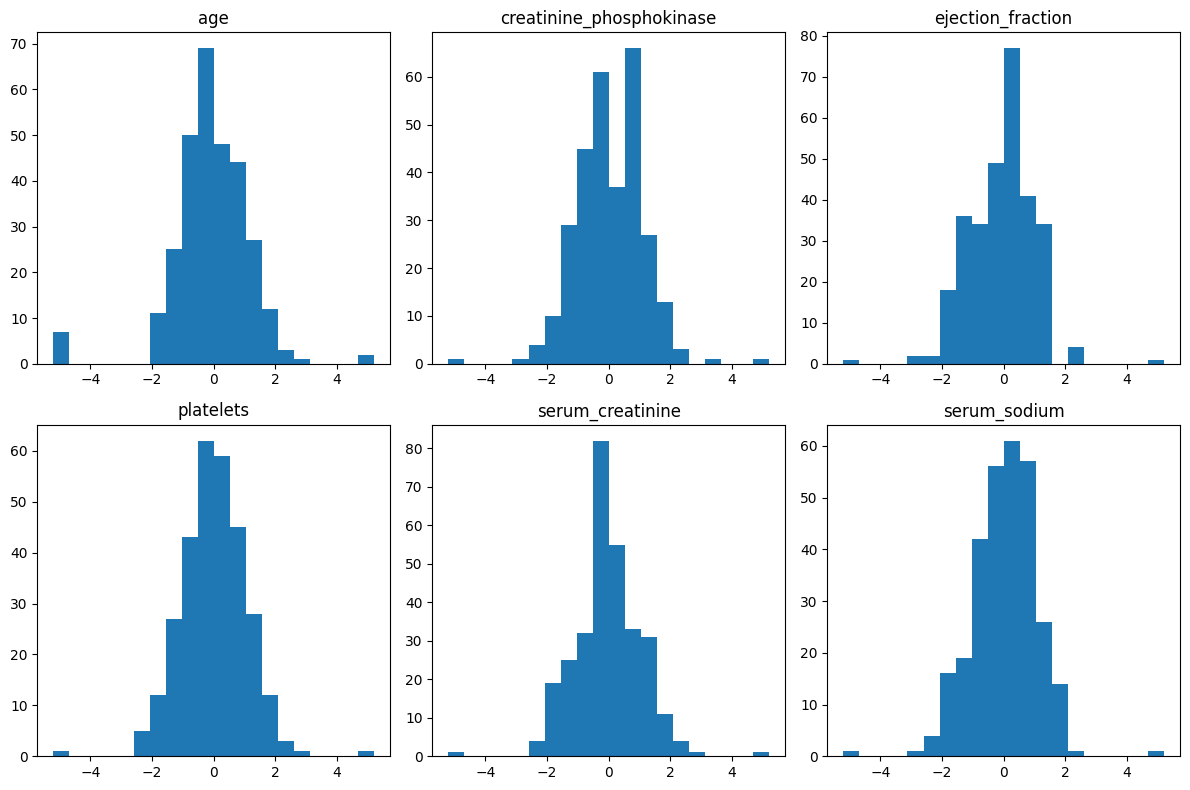

In [76]:
fig, axs = plt.subplots(2, 3)
fig.set_size_inches(12, 8)
axs[0, 0].hist(data_quantile_normal[:,0], bins = n_bins)
axs[0, 0].set_title('age')
axs[0, 1].hist(data_quantile_normal[:,1], bins = n_bins)
axs[0, 1].set_title('creatinine_phosphokinase')
axs[0, 2].hist(data_quantile_normal[:,2], bins = n_bins)
axs[0, 2].set_title('ejection_fraction')
axs[1, 0].hist(data_quantile_normal[:,3], bins = n_bins)
axs[1, 0].set_title('platelets')
axs[1, 1].hist(data_quantile_normal[:,4], bins = n_bins)
axs[1, 1].set_title('serum_creatinine')
axs[1, 2].hist(data_quantile_normal[:,5], bins = n_bins)
axs[1, 2].set_title('serum_sodium')
plt.tight_layout()
plt.show()

6. PowerTransformer


=== PowerTransformer ===


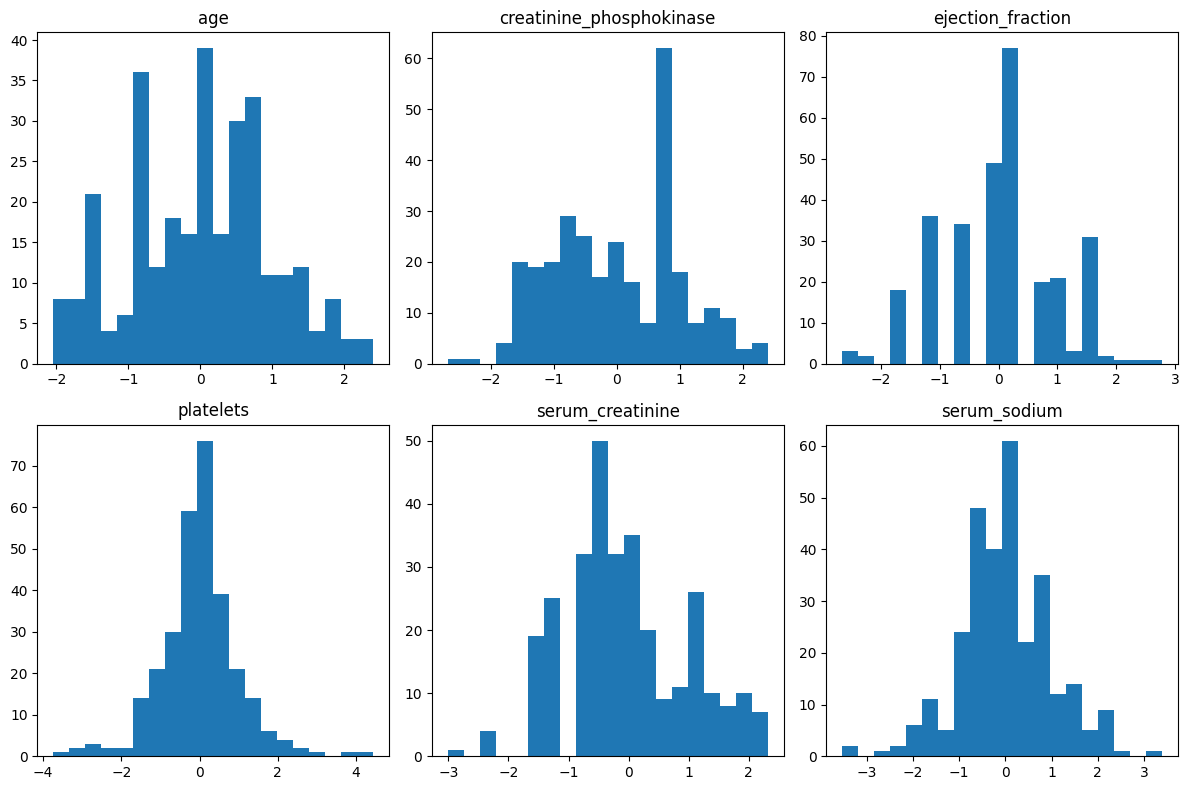

In [77]:
print("\n=== PowerTransformer ===")
power_transformer = preprocessing.PowerTransformer(method='yeo-johnson').fit(data)
data_power = power_transformer.transform(data)

fig, axs = plt.subplots(2, 3)
fig.set_size_inches(12, 8)
axs[0, 0].hist(data_power[:,0], bins = n_bins)
axs[0, 0].set_title('age')
axs[0, 1].hist(data_power[:,1], bins = n_bins)
axs[0, 1].set_title('creatinine_phosphokinase')
axs[0, 2].hist(data_power[:,2], bins = n_bins)
axs[0, 2].set_title('ejection_fraction')
axs[1, 0].hist(data_power[:,3], bins = n_bins)
axs[1, 0].set_title('platelets')
axs[1, 1].hist(data_power[:,4], bins = n_bins)
axs[1, 1].set_title('serum_creatinine')
axs[1, 2].hist(data_power[:,5], bins = n_bins)
axs[1, 2].set_title('serum_sodium')
plt.tight_layout()
plt.show()

## Дискретизация признаков

1. KBinsDiscretizer

In [78]:
from sklearn.preprocessing import KBinsDiscretizer

# Создание словаря с количеством интервалов для каждого признака
n_bins_dict = {
    'age': 3,
    'creatinine_phosphokinase': 4,
    'ejection_fraction': 3,
    'platelets': 10,
    'serum_creatinine': 2,
    'serum_sodium': 4
}

# Применение дискретизации к каждому признаку
data_discretized = np.zeros_like(data)
for i, col in enumerate(df.columns):
    kbd = KBinsDiscretizer(n_bins=n_bins_dict[col], encode='ordinal', strategy='uniform')
    data_discretized[:, i] = kbd.fit_transform(data[:, i].reshape(-1, 1)).flatten()

2. Гистограммы после дискретизации

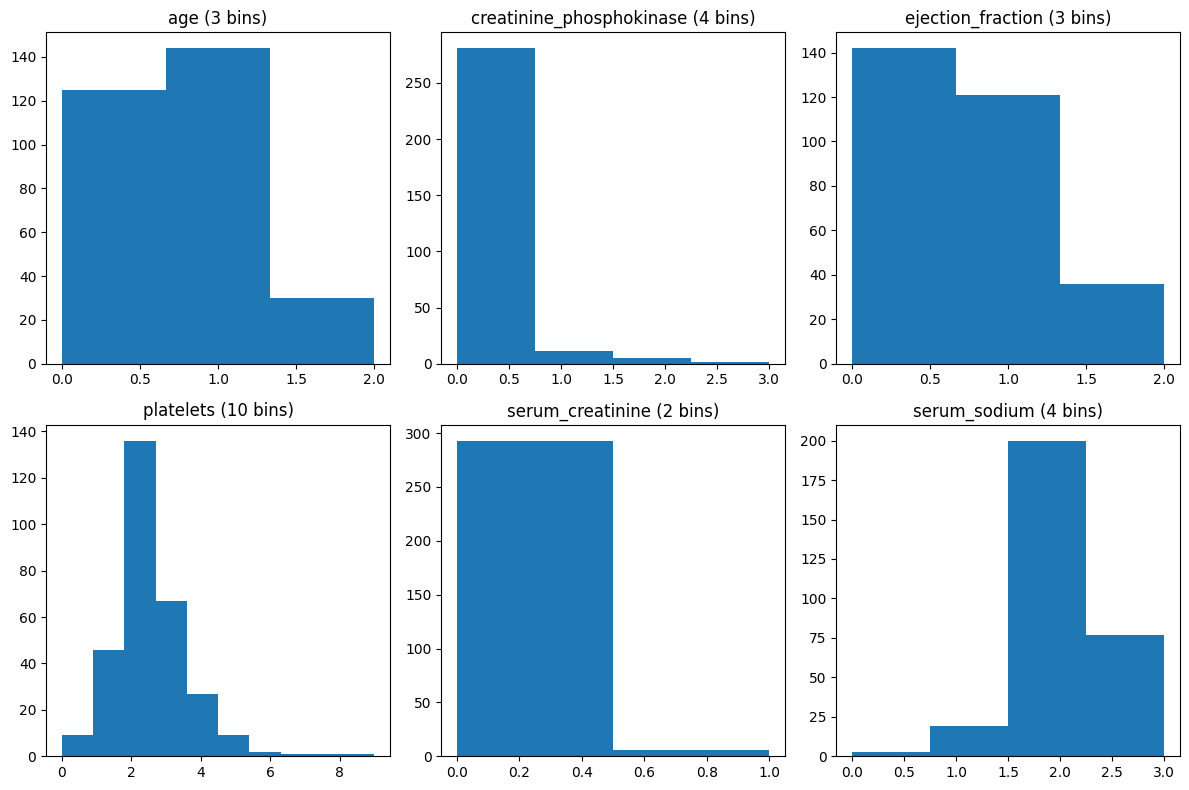

In [79]:
fig, axs = plt.subplots(2, 3)
fig.set_size_inches(12, 8)
axs[0, 0].hist(data_discretized[:,0], bins=n_bins_dict['age'])
axs[0, 0].set_title('age (3 bins)')
axs[0, 1].hist(data_discretized[:,1], bins=n_bins_dict['creatinine_phosphokinase'])
axs[0, 1].set_title('creatinine_phosphokinase (4 bins)')
axs[0, 2].hist(data_discretized[:,2], bins=n_bins_dict['ejection_fraction'])
axs[0, 2].set_title('ejection_fraction (3 bins)')
axs[1, 0].hist(data_discretized[:,3], bins=n_bins_dict['platelets'])
axs[1, 0].set_title('platelets (10 bins)')
axs[1, 1].hist(data_discretized[:,4], bins=n_bins_dict['serum_creatinine'])
axs[1, 1].set_title('serum_creatinine (2 bins)')
axs[1, 2].hist(data_discretized[:,5], bins=n_bins_dict['serum_sodium'])
axs[1, 2].set_title('serum_sodium (4 bins)')
plt.tight_layout()
plt.show()

Дискретизация признаков:
- Полученные результаты: каждый признак разделен на заданное количество интервалов
- На гистограммах видно количество наблюдений в каждом интервале
- Форма гистограмм изменилась на ступенчатую, отражающую дискретность

3. Вывод границ интервалов

In [80]:
print("\n=== Границы интервалов (bin_edges_) ===")
for i, col in enumerate(df.columns):
    kbd = KBinsDiscretizer(n_bins=n_bins_dict[col], encode='ordinal', strategy='uniform')
    kbd.fit(data[:, i].reshape(-1, 1))
    print(f"\n{col} (n_bins={n_bins_dict[col]}):")
    print(f"  bin_edges_: {kbd.bin_edges_[0]}")


=== Границы интервалов (bin_edges_) ===

age (n_bins=3):
  bin_edges_: [40.         58.33333333 76.66666667 95.        ]

creatinine_phosphokinase (n_bins=4):
  bin_edges_: [  23.  1982.5 3942.  5901.5 7861. ]

ejection_fraction (n_bins=3):
  bin_edges_: [14. 36. 58. 80.]

platelets (n_bins=10):
  bin_edges_: [ 25100. 107590. 190080. 272570. 355060. 437550. 520040. 602530. 685020.
 767510. 850000.]

serum_creatinine (n_bins=2):
  bin_edges_: [0.5  4.95 9.4 ]

serum_sodium (n_bins=4):
  bin_edges_: [113.   121.75 130.5  139.25 148.  ]


# Выводы

В ходе лабораторной работы были изучены основные методы предобработки данных из библиотеки Scikit-learn.

Стандартизация привела признаки к нулевому среднему и единичному отклонению. Масштабирование (MinMaxScaler, MaxAbsScaler, RobustScaler) изменило диапазон значений признаков. Нелинейные преобразования (QuantileTransformer, PowerTransformer) изменили форму распределения данных. Дискретизация (KBinsDiscretizer) преобразовала непрерывные признаки в категориальные.

Все методы предобработки позволяют подготовить данные для дальнейшего анализа и машинного обучения.